In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from xgboost import plot_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("../Data_Pre-processing/clean_data.csv")

In [3]:
X = df.drop("target", axis=1)
y = df["target"]

In [4]:
X = pd.get_dummies(X, drop_first=True)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Accuracy=", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy= 0.8478260869565217
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        82
           1       0.84      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



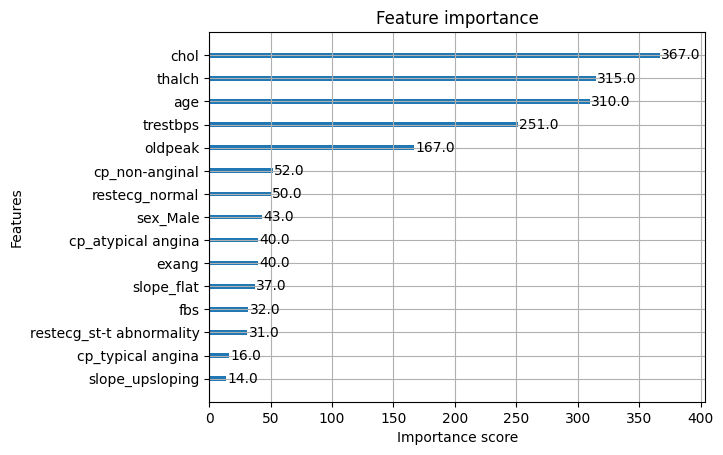

In [ ]:
plot_importance(xgb_model)
plt.show()

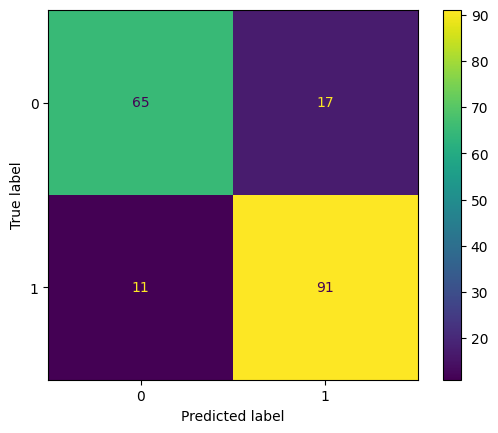

In [11]:
ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)

plt.show()